### SRResNet model

#### I : Učitavanje biblioteka i pripremljenih trening i validacionih skupova

In [1]:
import os
import random

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

# Fiksiranje random seed-a za reproducibilnost
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

X_train = np.load("../data/X_train.npy")
y_train = np.load("../data/y_train.npy")
X_val = np.load("../data/X_val.npy")
y_val = np.load("../data/y_val.npy")

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

X_train: (8000, 32, 32, 3)
y_train: (8000, 128, 128, 3)
X_val: (1000, 32, 32, 3)
y_val: (1000, 128, 128, 3)


#### II : Arhitektura SRResNet modela

##### 2.1) Rezidualni blok (Residual Block)

In [2]:
class ResidualBlock(nn.Module):
    def __init__(self, channels=64):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(channels)
        self.prelu = nn.PReLU()
        self.conv2 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(channels)

    def forward(self, x):
        residual = x
        out = self.prelu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        return out + residual

##### 2.2) SRResNet arhitektura

In [3]:
class SRResNet(nn.Module):
    def __init__(self, num_channels=3, num_res_blocks=16, scale_factor=4):
        super(SRResNet, self).__init__()

        self.entry = nn.Sequential(
            nn.Conv2d(num_channels, 64, kernel_size=9, padding=4),
            nn.PReLU()
        )

        self.res_blocks = nn.Sequential(
            *[ResidualBlock(64) for _ in range(num_res_blocks)]
        )

        self.mid_conv = nn.Sequential(
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64)
        )

        upsample_blocks = []
        for _ in range(int(np.log2(scale_factor))):
            upsample_blocks += [
                nn.Conv2d(64, 256, kernel_size=3, padding=1),
                nn.PixelShuffle(2),
                nn.PReLU()
            ]
        self.upsample = nn.Sequential(*upsample_blocks)

        self.exit = nn.Conv2d(64, num_channels, kernel_size=9, padding=4)

    def forward(self, x):
        out1 = self.entry(x)
        out = self.res_blocks(out1)
        out = self.mid_conv(out)
        out = out + out1
        out = self.upsample(out)
        out = self.exit(out)
        return out

##### 2.3) Instanciranje modela i broj parametara

In [4]:
SCALE = 4

model = SRResNet(num_res_blocks=16, scale_factor=SCALE)
num_params = sum(p.numel() for p in model.parameters())
print(f"Broj parametara SRResNet modela: {num_params:,}")

Broj parametara SRResNet modela: 1,549,462


#### III : Podešavanje treninga

##### 3.1) Podešavanje uređaja (device)

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
print("Koristi se uređaj:", device)

Koristi se uređaj: cpu


##### 3.2) Loss funkcija i optimizator

In [6]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

NUM_EPOCHS = 50
BATCH_SIZE = 16

##### 3.3) Priprema Dataset i DataLoader klasa

In [8]:
class SRDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        lr = torch.from_numpy(self.X[idx]).permute(2, 0, 1).float()
        hr = torch.from_numpy(self.y[idx]).permute(2, 0, 1).float()

        if lr.max() > 1.0:
            lr = lr / 255.0
        if hr.max() > 1.0:
            hr = hr / 255.0

        return lr, hr


train_dataset = SRDataset(X_train, y_train)
val_dataset = SRDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Broj trening batch-eva:", len(train_loader))
print("Broj validacionih batch-eva:", len(val_loader))

Broj trening batch-eva: 500
Broj validacionih batch-eva: 63


#### IV : Trening modela

In [9]:
train_losses = []
val_losses = []

best_val_loss = float("inf")
best_model_path = "../models/srresnet_best.pth"

for epoch in range(NUM_EPOCHS):

    model.train()
    running_train_loss = 0.0

    for lr_imgs, hr_imgs in train_loader:
        lr_imgs, hr_imgs = lr_imgs.to(device), hr_imgs.to(device)

        optimizer.zero_grad()
        outputs = model(lr_imgs)
        loss = criterion(outputs, hr_imgs)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item() * lr_imgs.size(0)

    epoch_train_loss = running_train_loss / len(train_dataset)
    train_losses.append(epoch_train_loss)

    model.eval()
    running_val_loss = 0.0

    with torch.no_grad():
        for lr_imgs, hr_imgs in val_loader:
            lr_imgs, hr_imgs = lr_imgs.to(device), hr_imgs.to(device)
            outputs = model(lr_imgs)
            loss = criterion(outputs, hr_imgs)
            running_val_loss += loss.item() * lr_imgs.size(0)

    epoch_val_loss = running_val_loss / len(val_dataset)
    val_losses.append(epoch_val_loss)

    print(f"Epoha [{epoch+1}/{NUM_EPOCHS}] | Train Loss: {epoch_train_loss:.6f} | Val Loss: {epoch_val_loss:.6f}")

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), best_model_path)
        print(f"  → Nov najbolji model sačuvan (Val Loss: {best_val_loss:.6f})")

print("\nTrening završen.")
print(f"Najbolji Val Loss: {best_val_loss:.6f}")

Epoha [1/50] | Train Loss: 0.013715 | Val Loss: 0.007381
  → Nov najbolji model sačuvan (Val Loss: 0.007381)
Epoha [2/50] | Train Loss: 0.005483 | Val Loss: 0.004940
  → Nov najbolji model sačuvan (Val Loss: 0.004940)
Epoha [3/50] | Train Loss: 0.004537 | Val Loss: 0.004579
  → Nov najbolji model sačuvan (Val Loss: 0.004579)
Epoha [4/50] | Train Loss: 0.004051 | Val Loss: 0.003973
  → Nov najbolji model sačuvan (Val Loss: 0.003973)
Epoha [5/50] | Train Loss: 0.003793 | Val Loss: 0.003823
  → Nov najbolji model sačuvan (Val Loss: 0.003823)
Epoha [6/50] | Train Loss: 0.003701 | Val Loss: 0.003801
  → Nov najbolji model sačuvan (Val Loss: 0.003801)
Epoha [7/50] | Train Loss: 0.003580 | Val Loss: 0.003585
  → Nov najbolji model sačuvan (Val Loss: 0.003585)
Epoha [8/50] | Train Loss: 0.003521 | Val Loss: 0.003677
Epoha [9/50] | Train Loss: 0.003440 | Val Loss: 0.003442
  → Nov najbolji model sačuvan (Val Loss: 0.003442)
Epoha [10/50] | Train Loss: 0.003365 | Val Loss: 0.003445
Epoha [11/50]

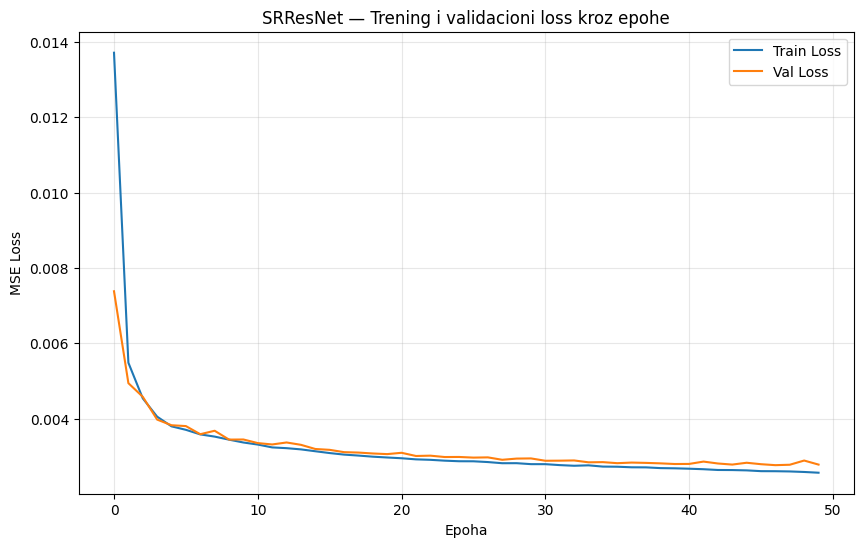

In [10]:
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epoha")
plt.ylabel("MSE Loss")
plt.title("SRResNet — Trening i validacioni loss kroz epohe")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

#### VI : Evaluacija na test skupu

##### 6.1) Učitavanje najboljeg modela

In [11]:
model = SRResNet(num_res_blocks=16, scale_factor=SCALE)
model.load_state_dict(torch.load("/Users/stasatonic/Rekonstrukcija-i-super-rezolucija-istorijskih-slika/models/srresnet_best.pth", map_location=device))
model = model.to(device)
model.eval()

print("Model uspešno učitan.")

Model uspešno učitan.


##### 6.1) Učitavanje test skupova (Set5, Set14)

In [12]:
set5 = np.load("/Users/stasatonic/Rekonstrukcija-i-super-rezolucija-istorijskih-slika/data/Set5_test.npz")
set14 = np.load("/Users/stasatonic/Rekonstrukcija-i-super-rezolucija-istorijskih-slika/data/Set14_test_x4.npz")

X_test_set5 = [set5[f"X_{i}"] for i in range(5)]
y_test_set5 = [set5[f"y_{i}"] for i in range(5)]

X_test_set14 = [set14[f"X_{i}"] for i in range(14)]
y_test_set14 = [set14[f"y_{i}"] for i in range(14)]

print("Set5 test slika:", len(X_test_set5))
print("Set14 test slika:", len(X_test_set14))

Set5 test slika: 5
Set14 test slika: 14


##### 6.3) Funkcija za evaluaciju (PSNR, SSIM)

In [13]:
def evaluate_on_set(model, X_list, y_list, device):
    psnr_scores = []
    ssim_scores = []

    model.eval()
    with torch.no_grad():
        for lr_img, hr_img in zip(X_list, y_list):

            lr_tensor = torch.from_numpy(lr_img).permute(2, 0, 1).float().unsqueeze(0).to(device)

            sr_tensor = model(lr_tensor)
            sr_img = sr_tensor.squeeze(0).permute(1, 2, 0).cpu().numpy()
            sr_img = np.clip(sr_img, 0, 1)

            psnr_val = psnr(hr_img, sr_img, data_range=1.0)
            ssim_val = ssim(hr_img, sr_img, data_range=1.0, channel_axis=2)

            psnr_scores.append(psnr_val)
            ssim_scores.append(ssim_val)

    return np.mean(psnr_scores), np.mean(ssim_scores)

##### 6.4) Rezultati evaluacije na Set5 i Set14

In [14]:
set5_psnr, set5_ssim = evaluate_on_set(model, X_test_set5, y_test_set5, device)
set14_psnr, set14_ssim = evaluate_on_set(model, X_test_set14, y_test_set14, device)

print("SRResNet — Rezultati evaluacije\n")
print(f"{'':10} {'PSNR':>10} {'SSIM':>10}")
print("-" * 32)
print(f"{'Set5:':10} {set5_psnr:>10.4f} {set5_ssim:>10.4f}")
print(f"{'Set14:':10} {set14_psnr:>10.4f} {set14_ssim:>10.4f}")

SRResNet — Rezultati evaluacije

                 PSNR       SSIM
--------------------------------
Set5:         28.8503     0.8468
Set14:        25.7176     0.7384


##### 6.5) Vizuelna provera rezultata

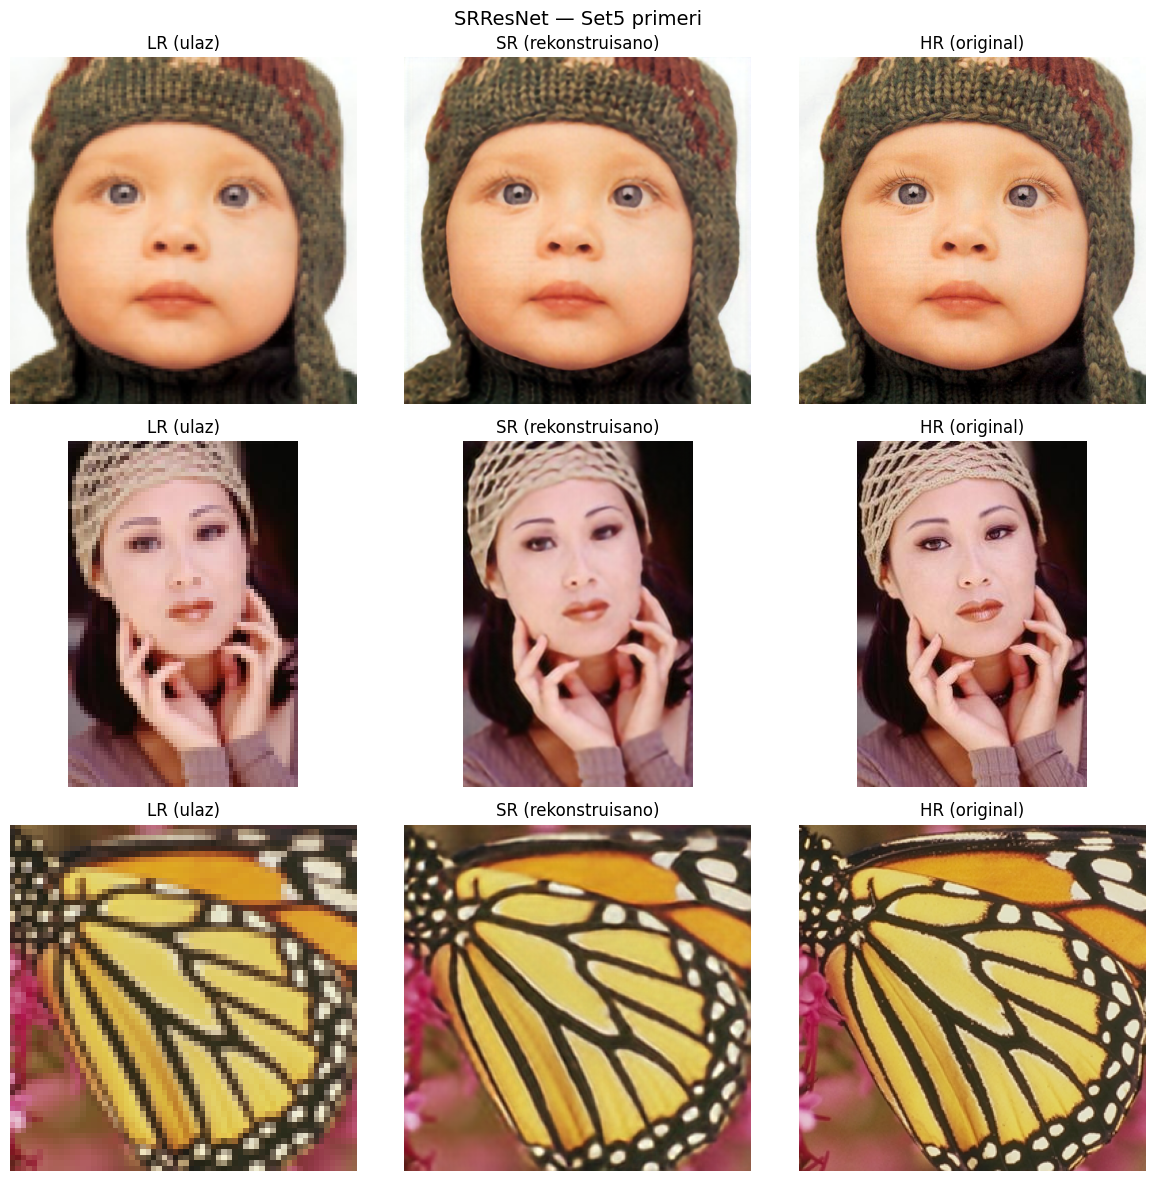

In [15]:
def show_lr_sr_hr(model, X_list, y_list, device, num_examples=3, title=""):
    indices = random.sample(range(len(X_list)), num_examples)

    fig, axes = plt.subplots(num_examples, 3, figsize=(12, 4 * num_examples))
    fig.suptitle(title, fontsize=14)

    model.eval()
    with torch.no_grad():
        for i, idx in enumerate(indices):
            lr_img = X_list[idx]
            hr_img = y_list[idx]

            lr_tensor = torch.from_numpy(lr_img).permute(2, 0, 1).float().unsqueeze(0).to(device)
            sr_tensor = model(lr_tensor)
            sr_img = sr_tensor.squeeze(0).permute(1, 2, 0).cpu().numpy()
            sr_img = np.clip(sr_img, 0, 1)

            axes[i, 0].imshow(lr_img)
            axes[i, 0].set_title("LR (ulaz)")
            axes[i, 0].axis("off")

            axes[i, 1].imshow(sr_img)
            axes[i, 1].set_title("SR (rekonstruisano)")
            axes[i, 1].axis("off")

            axes[i, 2].imshow(hr_img)
            axes[i, 2].set_title("HR (original)")
            axes[i, 2].axis("off")

    plt.tight_layout()
    plt.show()


show_lr_sr_hr(model, X_test_set5, y_test_set5, device, num_examples=3, title="SRResNet — Set5 primeri")